In [228]:
from transformer_architecture import Transformer

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [229]:
df = pd.read_csv("data/cleaned_dataset.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,179.426579,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,179.426579,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,211.382074,60.0,652230.0,33.93911,67.709953


In [230]:
df[df["Entity"] == "Somalia"]

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
2520,Somalia,2000,1.892501,0.4,93.28,0.23,0.0,0.00,0.000000,340.10217,11.22,490.000000,350.168162,25.0,637657.0,5.152149,46.199616
2521,Somalia,2001,4.504616,0.4,93.26,0.25,0.0,0.00,0.000000,332.43317,11.32,510.000000,350.168162,25.0,637657.0,5.152149,46.199616
2522,Somalia,2002,7.400000,0.5,92.58,0.26,0.0,0.00,0.000000,346.37854,11.39,569.999993,350.168162,25.0,637657.0,5.152149,46.199616
2523,Somalia,2003,9.708441,0.5,92.80,0.26,0.0,0.00,0.000000,334.05520,11.51,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2524,Somalia,2004,12.304850,0.6,93.00,0.26,0.0,0.00,0.000000,322.42703,11.48,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2525,Somalia,2005,14.900722,0.6,93.30,0.27,0.0,0.00,0.000000,314.66333,11.47,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2526,Somalia,2006,15.233786,0.7,93.47,0.28,0.0,0.00,0.000000,307.72528,11.60,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2527,Somalia,2007,20.100733,0.7,93.02,0.29,0.0,0.00,0.000000,302.79350,11.53,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2528,Somalia,2008,22.710230,0.8,93.37,0.30,0.0,0.00,0.000000,291.03380,11.74,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2529,Somalia,2009,25.329666,1.0,93.63,0.31,0.0,0.00,0.000000,283.20413,11.82,610.000014,350.168162,25.0,637657.0,5.152149,46.199616


# Data Processing

In [231]:
SEQ_LEN = 8
VAL_TIME = 1
TEST_TIME = 1
OOD_TEST_TIME = 2

### Train Val Test Splitting

In [232]:
entity = df["Entity"].unique()
year = df["Year"].unique()
year_start = np.arange(year.min(), year.max() - SEQ_LEN + 1, 1)
print(year_start)
len(entity), len(year), len(year_start)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


(145, 21, 13)

In [233]:
train_year = year_start[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME]
val_year = year_start[- VAL_TIME - TEST_TIME - OOD_TEST_TIME: - TEST_TIME - OOD_TEST_TIME]
test_year = year_start[- TEST_TIME - OOD_TEST_TIME: - OOD_TEST_TIME]
ood_test_year = year_start[- OOD_TEST_TIME:]
train_year, val_year, test_year, ood_test_year

(array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]),
 array([2009]),
 array([2010]),
 array([2011, 2012]))

### Normalization

In [234]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [235]:
scaler_years = set(year[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME])
scaler_years

{np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)}

In [236]:
scaler_df = df[df["Year"].isin(scaler_years)].drop(columns=["Entity", "Year"])

In [237]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [238]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])

df_global = df.drop(columns=["Entity"]).groupby('Year', as_index=False).mean()
df_global.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,2000,-0.173365,-0.102433,0.055485,-0.053051,-0.000135,-0.077248,0.011062,-0.038259,0.242942,-0.041096,-0.275143,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
1,2001,-0.155280,-0.088909,0.039796,-0.050245,0.005179,-0.082559,-0.013827,-0.035893,0.212047,-0.038231,-0.280080,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
2,2002,-0.128914,-0.075306,0.036260,-0.043046,0.005462,-0.076877,-0.003851,-0.024942,0.173836,-0.036085,-0.258630,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
3,2003,-0.108627,-0.061324,0.023585,-0.034198,0.001520,-0.074998,-0.019013,-0.011661,0.178610,-0.027841,-0.190461,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
4,2004,-0.088583,-0.048111,0.018931,-0.026900,0.011044,-0.060752,-0.014136,0.006960,0.150179,-0.019054,-0.121281,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18


### Entity - Year pair

In [239]:
def generate_pair(years):
    pairs = []

    for year in years:
        for e in entity:
            pairs.append((e, year))

    return pairs

In [240]:
ds_train = generate_pair(train_year)
ds_val = generate_pair(val_year)
ds_test = generate_pair(test_year)
ds_ood_test = generate_pair(ood_test_year)

len(ds_train), len(ds_val), len(ds_test), len(ds_ood_test)

(1305, 145, 145, 290)

### Data Loader

In [241]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [242]:
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-4

HIDDEN_DIM = 384

In [243]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
ood_test_loader = DataLoader(ds_ood_test, batch_size = BATCH_SIZE)

In [244]:
col_count = len(df_global.columns)

model = Transformer(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count,
    encoder_attention_heads=4,
    encoder_blocks=6,
    decoder_attention_heads=4,
    decoder_blocks=6,
    dropout=0.15,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.1),
    num_training_steps=EPOCHS*len(train_loader)
)

In [245]:
df = df.sort_values(["Entity", "Year"]).set_index(["Entity", "Year"], drop=False)
df = df.drop(columns=["Entity"])
df_global = df_global.sort_values("Year").set_index("Year", drop=False)

entity_groups = {
    k: torch.tensor(v.values) for k, v in df.groupby(level=0)
}
global_array = torch.tensor(df_global.values)
years_index = {k: v for v, k in enumerate(df_global.index.to_numpy())}
years_index

{np.int64(2000): 0,
 np.int64(2001): 1,
 np.int64(2002): 2,
 np.int64(2003): 3,
 np.int64(2004): 4,
 np.int64(2005): 5,
 np.int64(2006): 6,
 np.int64(2007): 7,
 np.int64(2008): 8,
 np.int64(2009): 9,
 np.int64(2010): 10,
 np.int64(2011): 11,
 np.int64(2012): 12,
 np.int64(2013): 13,
 np.int64(2014): 14,
 np.int64(2015): 15,
 np.int64(2016): 16,
 np.int64(2017): 17,
 np.int64(2018): 18,
 np.int64(2019): 19,
 np.int64(2020): 20}

# Training Loop

In [246]:
def load_tensor(entities, years):
    regional_data = []
    global_data = []

    for entity, year in zip(entities, years):
        year = int(year)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(entity_groups[entity][years_index[year] : years_index[year + SEQ_LEN] + 1])
        global_data.append(global_array[years_index[year] : years_index[year + SEQ_LEN]])


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    global_data = torch.stack(global_data).to(DEVICE, torch.float32)
    return regional_data, global_data

In [247]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [248]:
for e in range(EPOCHS):
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, 1:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss.item()

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.shape[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count*SEQ_LEN))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    with torch.no_grad():
        for entities, years in tqdm(val_loader, desc=f"               Val"):
            regional_data, global_data = load_tensor(entities, years)
            pred = model(global_data, regional_data[:, :-1])
            ground_truth = regional_data[:, -1]
            pred = pred[:, -1]
        

            loss = criterion(pred, ground_truth)
            val_loss += loss.item()

            val_se += ((pred - ground_truth)**2).sum().item()
            val_count += pred.shape[0]

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count*SEQ_LEN))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

Epoch   1 Training: 100%|██████████| 41/41 [00:06<00:00,  6.42it/s]


        Train Loss: 219.9664649032965, RMSE = 517.310018804542


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.10it/s]


          Val Loss: 213.5767364501953, RMSE = 182.4347238008046
                lr: 5e-06



Epoch   2 Training: 100%|██████████| 41/41 [00:04<00:00,  9.03it/s]


        Train Loss: 199.37722182855373, RMSE = 507.5044129057145


               Val: 100%|██████████| 5/5 [00:00<00:00, 44.34it/s]


          Val Loss: 182.43043823242186, RMSE = 177.25629457234302
                lr: 1e-05



Epoch   3 Training: 100%|██████████| 41/41 [00:05<00:00,  7.45it/s]


        Train Loss: 161.49215251643483, RMSE = 488.9811869074569


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.05it/s]


          Val Loss: 140.54934692382812, RMSE = 169.20318840233844
                lr: 1.5e-05



Epoch   4 Training: 100%|██████████| 41/41 [00:05<00:00,  7.44it/s]


        Train Loss: 123.70464269126335, RMSE = 461.57602786747464


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.13it/s]


          Val Loss: 112.38553771972656, RMSE = 157.21145846411383
                lr: 2e-05



Epoch   5 Training: 100%|██████████| 41/41 [00:07<00:00,  5.42it/s]


        Train Loss: 104.92290999249714, RMSE = 416.64781888405815


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.25it/s]


          Val Loss: 95.61156463623047, RMSE = 134.76164862324583
                lr: 2.5e-05



Epoch   6 Training: 100%|██████████| 41/41 [00:05<00:00,  6.93it/s]


        Train Loss: 81.79749279487424, RMSE = 324.46946130851677


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.41it/s]


          Val Loss: 62.49322738647461, RMSE = 87.91690887638913
                lr: 3e-05



Epoch   7 Training: 100%|██████████| 41/41 [00:06<00:00,  6.33it/s]


        Train Loss: 37.683492730303506, RMSE = 155.25330283967637


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.95it/s]


          Val Loss: 1.5008462190628051, RMSE = 1.4107605650327157
                lr: 3.5e-05



Epoch   8 Training: 100%|██████████| 41/41 [00:05<00:00,  7.37it/s]


        Train Loss: 7.364406585693359, RMSE = 13.02541455327248


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.49it/s]


          Val Loss: 0.8048962354660034, RMSE = 0.5700235953181073
                lr: 4e-05



Epoch   9 Training: 100%|██████████| 41/41 [00:05<00:00,  7.83it/s]


        Train Loss: 6.038038265414354, RMSE = 8.60841533198517


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.39it/s]


          Val Loss: 1.3429775714874268, RMSE = 0.8724095074466602
                lr: 4.5e-05



Epoch  10 Training: 100%|██████████| 41/41 [00:05<00:00,  7.75it/s]


        Train Loss: 5.790521784526546, RMSE = 8.261342352621844


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.22it/s]


          Val Loss: 1.332680082321167, RMSE = 0.8472530796164558
                lr: 5e-05



Epoch  11 Training: 100%|██████████| 41/41 [00:04<00:00,  8.21it/s]


        Train Loss: 5.512486004247898, RMSE = 7.9086463787995624


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.53it/s]


          Val Loss: 0.8076641440391541, RMSE = 0.6400744306100428
                lr: 5.500000000000001e-05



Epoch  12 Training: 100%|██████████| 41/41 [00:05<00:00,  7.24it/s]


        Train Loss: 5.204235646782852, RMSE = 7.514928637705566


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.00it/s]


          Val Loss: 1.1463419914245605, RMSE = 0.7657418555813332
                lr: 6e-05



Epoch  13 Training: 100%|██████████| 41/41 [00:04<00:00,  8.98it/s]


        Train Loss: 4.9700746768858375, RMSE = 7.211114945404554


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.49it/s]


          Val Loss: 0.8392534732818604, RMSE = 0.5891148501282898
                lr: 6.500000000000001e-05



Epoch  14 Training: 100%|██████████| 41/41 [00:05<00:00,  7.65it/s]


        Train Loss: 4.647085457313351, RMSE = 6.810897176577854


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.09it/s]


          Val Loss: 0.810004723072052, RMSE = 0.570505447435932
                lr: 7e-05



Epoch  15 Training: 100%|██████████| 41/41 [00:04<00:00,  8.44it/s]


        Train Loss: 4.308546310517846, RMSE = 6.338561972832726


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.72it/s]


          Val Loss: 0.9441917896270752, RMSE = 0.6940392110900573
                lr: 7.500000000000001e-05



Epoch  16 Training: 100%|██████████| 41/41 [00:04<00:00,  8.36it/s]


        Train Loss: 4.000891714561276, RMSE = 5.954106814080865


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.35it/s]


          Val Loss: 0.6494612693786621, RMSE = 0.5118541983098733
                lr: 8e-05



Epoch  17 Training: 100%|██████████| 41/41 [00:04<00:00,  8.95it/s]


        Train Loss: 3.6701652422183897, RMSE = 5.529011039921764


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.18it/s]


          Val Loss: 0.964131212234497, RMSE = 0.6988435400274438
                lr: 8.5e-05



Epoch  18 Training: 100%|██████████| 41/41 [00:05<00:00,  7.99it/s]


        Train Loss: 3.3797713198312898, RMSE = 5.163570892423302


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.05it/s]


          Val Loss: 0.8292754530906677, RMSE = 0.5971388738193959
                lr: 9e-05



Epoch  19 Training: 100%|██████████| 41/41 [00:05<00:00,  7.21it/s]


        Train Loss: 3.071187182170589, RMSE = 4.752203760097145


               Val: 100%|██████████| 5/5 [00:00<00:00, 48.79it/s]


          Val Loss: 0.7402982711791992, RMSE = 0.6221658151278258
                lr: 9.5e-05



Epoch  20 Training: 100%|██████████| 41/41 [00:05<00:00,  7.77it/s]


        Train Loss: 2.7515869140625, RMSE = 4.333129403116171


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.87it/s]


          Val Loss: 0.5888952732086181, RMSE = 0.43723787996308267
                lr: 0.0001



Epoch  21 Training: 100%|██████████| 41/41 [00:05<00:00,  7.39it/s]


        Train Loss: 2.4442309577290606, RMSE = 3.9633868255255003


               Val: 100%|██████████| 5/5 [00:00<00:00, 42.98it/s]


          Val Loss: 0.7230243682861328, RMSE = 0.5840235020742652
                lr: 9.999238475781957e-05



Epoch  22 Training: 100%|██████████| 41/41 [00:04<00:00,  8.54it/s]


        Train Loss: 2.195437053354775, RMSE = 3.643057492124483


               Val: 100%|██████████| 5/5 [00:00<00:00, 44.32it/s]


          Val Loss: 1.0208940744400024, RMSE = 0.7901074617877728
                lr: 9.99695413509548e-05



Epoch  23 Training: 100%|██████████| 41/41 [00:05<00:00,  7.64it/s]


        Train Loss: 1.930294906220785, RMSE = 3.2606134184751925


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.55it/s]


          Val Loss: 0.7032422542572021, RMSE = 0.6300150013324095
                lr: 9.99314767377287e-05



Epoch  24 Training: 100%|██████████| 41/41 [00:04<00:00,  8.94it/s]


        Train Loss: 1.6886053434232386, RMSE = 2.911292375427955


               Val: 100%|██████████| 5/5 [00:00<00:00, 48.04it/s]


          Val Loss: 0.3375710964202881, RMSE = 0.3386717482833889
                lr: 9.987820251299122e-05



Epoch  25 Training: 100%|██████████| 41/41 [00:06<00:00,  6.82it/s]


        Train Loss: 1.466349630821042, RMSE = 2.5952155048865615


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.80it/s]


          Val Loss: 0.6108488798141479, RMSE = 0.4782329672134669
                lr: 9.980973490458728e-05



Epoch  26 Training: 100%|██████████| 41/41 [00:05<00:00,  7.87it/s]


        Train Loss: 1.2852900464360306, RMSE = 2.3474039654250523


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.12it/s]


          Val Loss: 0.35429794788360597, RMSE = 0.3349356155741613
                lr: 9.972609476841367e-05



Epoch  27 Training: 100%|██████████| 41/41 [00:04<00:00,  9.51it/s]


        Train Loss: 1.126227163686985, RMSE = 2.119520802127886


               Val: 100%|██████████| 5/5 [00:00<00:00, 52.24it/s]


          Val Loss: 0.38281952738761904, RMSE = 0.3691832480402733
                lr: 9.962730758206611e-05



Epoch  28 Training: 100%|██████████| 41/41 [00:05<00:00,  7.32it/s]


        Train Loss: 0.9884528037978382, RMSE = 1.9277812913716077


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.50it/s]


          Val Loss: 0.3756560504436493, RMSE = 0.3466657478453571
                lr: 9.951340343707852e-05



Epoch  29 Training: 100%|██████████| 41/41 [00:05<00:00,  7.56it/s]


        Train Loss: 0.8928308225259548, RMSE = 1.7723301691813682


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.88it/s]


          Val Loss: 0.4293902277946472, RMSE = 0.36833305084881146
                lr: 9.938441702975689e-05



Epoch  30 Training: 100%|██████████| 41/41 [00:05<00:00,  7.14it/s]


        Train Loss: 0.7663283130017723, RMSE = 1.589641570219482


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.50it/s]


          Val Loss: 0.4836731910705566, RMSE = 0.3889742024283033
                lr: 9.924038765061042e-05



Epoch  31 Training: 100%|██████████| 41/41 [00:05<00:00,  7.32it/s]


        Train Loss: 0.7022709381289598, RMSE = 1.4858437557222444


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.86it/s]


          Val Loss: 0.32733492851257323, RMSE = 0.3175086734445669
                lr: 9.908135917238321e-05



Epoch  32 Training: 100%|██████████| 41/41 [00:04<00:00,  8.68it/s]


        Train Loss: 0.6280592549137953, RMSE = 1.3779557526267827


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.94it/s]


          Val Loss: 0.3880584180355072, RMSE = 0.35087713441773266
                lr: 9.890738003669029e-05



Epoch  33 Training: 100%|██████████| 41/41 [00:05<00:00,  8.17it/s]


        Train Loss: 0.5799184078123512, RMSE = 1.306845217923035


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.52it/s]


          Val Loss: 0.3046800196170807, RMSE = 0.3049924880591166
                lr: 9.871850323926177e-05



Epoch  34 Training: 100%|██████████| 41/41 [00:05<00:00,  7.54it/s]


        Train Loss: 0.5198465287685394, RMSE = 1.2187647559197117


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.99it/s]


          Val Loss: 0.32545056343078616, RMSE = 0.31776601793513354
                lr: 9.851478631379982e-05



Epoch  35 Training: 100%|██████████| 41/41 [00:05<00:00,  7.35it/s]


        Train Loss: 0.4809371160297859, RMSE = 1.1522942974221386


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.94it/s]


          Val Loss: 0.3395631551742554, RMSE = 0.31325923899103253
                lr: 9.829629131445342e-05



Epoch  36 Training: 100%|██████████| 41/41 [00:05<00:00,  8.03it/s]


        Train Loss: 0.4634971342435697, RMSE = 1.1150480412347452


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.47it/s]


          Val Loss: 0.30034010410308837, RMSE = 0.29902179280841334
                lr: 9.806308479691595e-05



Epoch  37 Training: 100%|██████████| 41/41 [00:05<00:00,  7.17it/s]


        Train Loss: 0.4515699540696493, RMSE = 1.114520829718727


               Val: 100%|██████████| 5/5 [00:00<00:00, 44.03it/s]


          Val Loss: 0.29457696676254275, RMSE = 0.30304420172747326
                lr: 9.781523779815179e-05



Epoch  38 Training: 100%|██████████| 41/41 [00:05<00:00,  7.60it/s]


        Train Loss: 0.399405383482212, RMSE = 1.014106160839746


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.92it/s]


          Val Loss: 0.3314539134502411, RMSE = 0.3116713765043061
                lr: 9.755282581475769e-05



Epoch  39 Training: 100%|██████████| 41/41 [00:05<00:00,  7.50it/s]


        Train Loss: 0.3849199254338334, RMSE = 0.9991792182404247


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.64it/s]


          Val Loss: 0.26042082011699674, RMSE = 0.27795759451914615
                lr: 9.727592877996585e-05



Epoch  40 Training: 100%|██████████| 41/41 [00:04<00:00,  8.21it/s]


        Train Loss: 0.3618501323025401, RMSE = 0.9582641942650193


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.87it/s]


          Val Loss: 0.22644529342651368, RMSE = 0.26178044383713506
                lr: 9.698463103929542e-05



Epoch  41 Training: 100%|██████████| 41/41 [00:04<00:00,  9.27it/s]


        Train Loss: 0.3628622511538064, RMSE = 0.9676675688169483


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.26it/s]


          Val Loss: 0.32371532917022705, RMSE = 0.3025541624173042
                lr: 9.667902132486009e-05



Epoch  42 Training: 100%|██████████| 41/41 [00:04<00:00,  9.17it/s]


        Train Loss: 0.36016551859495116, RMSE = 0.9464717273792835


               Val: 100%|██████████| 5/5 [00:00<00:00, 32.03it/s]


          Val Loss: 0.14767205715179443, RMSE = 0.2082884570272502
                lr: 9.635919272833938e-05



Epoch  43 Training: 100%|██████████| 41/41 [00:04<00:00,  9.68it/s]


        Train Loss: 0.32744763537151056, RMSE = 0.8906302948671441


               Val: 100%|██████████| 5/5 [00:00<00:00, 48.14it/s]


          Val Loss: 0.17924695312976838, RMSE = 0.22888092784482214
                lr: 9.602524267262203e-05



Epoch  44 Training: 100%|██████████| 41/41 [00:04<00:00,  8.24it/s]


        Train Loss: 0.35054439996800774, RMSE = 0.971615261457625


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.47it/s]


          Val Loss: 0.1658791035413742, RMSE = 0.2207088801472034
                lr: 9.567727288213005e-05



Epoch  45 Training: 100%|██████████| 41/41 [00:05<00:00,  7.57it/s]


        Train Loss: 0.33905036529389826, RMSE = 0.9231304158822909


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.57it/s]


          Val Loss: 0.18490130305290223, RMSE = 0.23047338377387103
                lr: 9.53153893518325e-05



Epoch  46 Training: 100%|██████████| 41/41 [00:05<00:00,  7.17it/s]


        Train Loss: 0.3804349034297757, RMSE = 1.014709549366465


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.81it/s]


          Val Loss: 0.21095122992992402, RMSE = 0.244595357088463
                lr: 9.493970231495835e-05



Epoch  47 Training: 100%|██████████| 41/41 [00:05<00:00,  7.19it/s]


        Train Loss: 0.3144354340506763, RMSE = 0.8768348977104103


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.38it/s]


          Val Loss: 0.30748777389526366, RMSE = 0.29801983812614086
                lr: 9.45503262094184e-05



Epoch  48 Training: 100%|██████████| 41/41 [00:05<00:00,  7.22it/s]


        Train Loss: 0.3018862147156785, RMSE = 0.8411410062837458


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.31it/s]


          Val Loss: 0.2701212644577026, RMSE = 0.27570169875331185
                lr: 9.414737964294636e-05



Epoch  49 Training: 100%|██████████| 41/41 [00:04<00:00, 10.00it/s]


        Train Loss: 0.2942797607038079, RMSE = 0.8392600408369544


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.86it/s]


          Val Loss: 0.22900237143039703, RMSE = 0.2532422355731307
                lr: 9.373098535696979e-05



Epoch  50 Training: 100%|██████████| 41/41 [00:04<00:00,  9.08it/s]


        Train Loss: 0.30494882675205787, RMSE = 0.8667392612614997


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.95it/s]


          Val Loss: 0.1754298746585846, RMSE = 0.22427459611649478
                lr: 9.330127018922194e-05



Epoch  51 Training: 100%|██████████| 41/41 [00:04<00:00,  8.48it/s]


        Train Loss: 0.2510345247460575, RMSE = 0.7544012074065788


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.71it/s]


          Val Loss: 0.15161212384700776, RMSE = 0.20757719192908075
                lr: 9.285836503510562e-05



Epoch  52 Training: 100%|██████████| 41/41 [00:04<00:00,  8.48it/s]


        Train Loss: 0.2701685315952068, RMSE = 0.7804385832242517


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.29it/s]


          Val Loss: 0.24639489650726318, RMSE = 0.2607252424612236
                lr: 9.24024048078213e-05



Epoch  53 Training: 100%|██████████| 41/41 [00:05<00:00,  7.86it/s]


        Train Loss: 0.24215118477984174, RMSE = 0.7383200212590361


               Val: 100%|██████████| 5/5 [00:00<00:00, 47.14it/s]


          Val Loss: 0.1824000895023346, RMSE = 0.22704799946009793
                lr: 9.193352839727121e-05



Epoch  54 Training: 100%|██████████| 41/41 [00:04<00:00,  8.69it/s]


        Train Loss: 0.29472101461596606, RMSE = 0.9240096781105596


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.85it/s]


          Val Loss: 0.40922472476959226, RMSE = 0.456235715473994
                lr: 9.145187862775209e-05



Epoch  55 Training: 100%|██████████| 41/41 [00:05<00:00,  7.20it/s]


        Train Loss: 0.3391865397371897, RMSE = 1.0485987020968575


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.05it/s]


          Val Loss: 0.2957933783531189, RMSE = 0.3178347699534599
                lr: 9.09576022144496e-05



Epoch  56 Training: 100%|██████████| 41/41 [00:05<00:00,  7.28it/s]


        Train Loss: 0.2905632279268125, RMSE = 0.8645933228060785


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.67it/s]


          Val Loss: 0.43086560964584353, RMSE = 0.37742850470531203
                lr: 9.045084971874738e-05



Epoch  57 Training: 100%|██████████| 41/41 [00:06<00:00,  6.36it/s]


        Train Loss: 0.24424800240411992, RMSE = 0.744836456323285


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.29it/s]


          Val Loss: 0.2722410440444946, RMSE = 0.2754925597730968
                lr: 8.993177550236464e-05



Epoch  58 Training: 100%|██████████| 41/41 [00:06<00:00,  6.52it/s]


        Train Loss: 0.259590646115745, RMSE = 0.8421396980752065


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.42it/s]


          Val Loss: 0.3674635112285614, RMSE = 0.33828247901260045
                lr: 8.940053768033609e-05



Epoch  59 Training: 100%|██████████| 41/41 [00:06<00:00,  6.73it/s]


        Train Loss: 0.30322796833224414, RMSE = 0.8985426447225058


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.35it/s]


          Val Loss: 0.203152596950531, RMSE = 0.23937688947491548
                lr: 8.885729807284856e-05



Epoch  60 Training: 100%|██████████| 41/41 [00:04<00:00,  8.81it/s]


        Train Loss: 0.21854010406063823, RMSE = 0.6911189280471087


               Val: 100%|██████████| 5/5 [00:00<00:00, 42.34it/s]


          Val Loss: 0.14186417162418366, RMSE = 0.19867570072789942
                lr: 8.83022221559489e-05



Epoch  61 Training: 100%|██████████| 41/41 [00:04<00:00,  9.22it/s]


        Train Loss: 0.20121530134503435, RMSE = 0.6577083825509665


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.49it/s]


          Val Loss: 0.19511444568634034, RMSE = 0.22736741010779118
                lr: 8.773547901113862e-05



Epoch  62 Training: 100%|██████████| 41/41 [00:04<00:00,  8.26it/s]


        Train Loss: 0.23230080124808522, RMSE = 0.7209680214590519


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.60it/s]


          Val Loss: 0.1387844681739807, RMSE = 0.19724994778160404
                lr: 8.715724127386972e-05



Epoch  63 Training: 100%|██████████| 41/41 [00:04<00:00,  8.26it/s]


        Train Loss: 0.23257344088903287, RMSE = 0.7640094857735907


               Val: 100%|██████████| 5/5 [00:00<00:00, 47.72it/s]


          Val Loss: 0.27187379598617556, RMSE = 0.2822357835299913
                lr: 8.656768508095853e-05



Epoch  64 Training: 100%|██████████| 41/41 [00:05<00:00,  7.55it/s]


        Train Loss: 0.23056731173178044, RMSE = 0.7411606536634966


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.97it/s]


          Val Loss: 0.2746073007583618, RMSE = 0.2984444990162085
                lr: 8.596699001693255e-05



Epoch  65 Training: 100%|██████████| 41/41 [00:05<00:00,  7.52it/s]


        Train Loss: 0.23178432445700575, RMSE = 0.7541502915126735


               Val: 100%|██████████| 5/5 [00:00<00:00, 55.11it/s]


          Val Loss: 0.21305760145187377, RMSE = 0.25032878828156346
                lr: 8.535533905932738e-05



Epoch  66 Training: 100%|██████████| 41/41 [00:06<00:00,  6.44it/s]


        Train Loss: 0.21549891953061268, RMSE = 0.7210841730341141


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.23it/s]


          Val Loss: 0.20960528552532195, RMSE = 0.23844740677349247
                lr: 8.473291852294987e-05



Epoch  67 Training: 100%|██████████| 41/41 [00:06<00:00,  6.61it/s]


        Train Loss: 0.22168740593805547, RMSE = 0.7249559218466144


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.15it/s]


          Val Loss: 0.22512640655040742, RMSE = 0.257179104019072
                lr: 8.409991800312493e-05



Epoch  68 Training: 100%|██████████| 41/41 [00:05<00:00,  7.76it/s]


        Train Loss: 0.21421202835513325, RMSE = 0.7120336708240526


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.81it/s]


          Val Loss: 0.15501096546649934, RMSE = 0.20403197196789077
                lr: 8.345653031794292e-05



Epoch  69 Training: 100%|██████████| 41/41 [00:05<00:00,  7.46it/s]


        Train Loss: 0.20230309883268868, RMSE = 0.6874335671126708


               Val: 100%|██████████| 5/5 [00:00<00:00, 12.44it/s]


          Val Loss: 0.19624641239643098, RMSE = 0.23209569698818217
                lr: 8.280295144952536e-05



Epoch  70 Training: 100%|██████████| 41/41 [00:04<00:00,  8.40it/s]


        Train Loss: 0.19409208690247884, RMSE = 0.6698536333428196


               Val: 100%|██████████| 5/5 [00:00<00:00, 49.39it/s]


          Val Loss: 0.19427627921104432, RMSE = 0.23329714171817606
                lr: 8.213938048432697e-05



Epoch  71 Training: 100%|██████████| 41/41 [00:06<00:00,  6.48it/s]


        Train Loss: 0.1869691664852747, RMSE = 0.6546433850292724


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.68it/s]


          Val Loss: 0.17500768303871156, RMSE = 0.223264231764271
                lr: 8.146601955249188e-05



Epoch  72 Training: 100%|██████████| 41/41 [00:04<00:00,  8.91it/s]


        Train Loss: 0.17770856764258408, RMSE = 0.633428973818824


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.60it/s]


          Val Loss: 0.10985711216926575, RMSE = 0.17284673717131813
                lr: 8.07830737662829e-05



Epoch  73 Training: 100%|██████████| 41/41 [00:05<00:00,  7.29it/s]


        Train Loss: 0.1621308652002637, RMSE = 0.5871286720256884


               Val: 100%|██████████| 5/5 [00:00<00:00, 54.49it/s]


          Val Loss: 0.08987118452787399, RMSE = 0.1559314532435863
                lr: 8.009075115760243e-05



Epoch  74 Training: 100%|██████████| 41/41 [00:06<00:00,  5.93it/s]


        Train Loss: 0.15563524241854504, RMSE = 0.5747281112452963


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.04it/s]


          Val Loss: 0.12613445073366164, RMSE = 0.1835146984990239
                lr: 7.938926261462366e-05



Epoch  75 Training: 100%|██████████| 41/41 [00:05<00:00,  8.18it/s]


        Train Loss: 0.19745898828273867, RMSE = 0.7267017482989132


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.73it/s]


          Val Loss: 0.2509576231241226, RMSE = 0.3352242074567564
                lr: 7.86788218175523e-05



Epoch  76 Training: 100%|██████████| 41/41 [00:05<00:00,  7.34it/s]


        Train Loss: 0.23369889397446703, RMSE = 0.8949439229642109


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.14it/s]


          Val Loss: 0.17588317692279815, RMSE = 0.22502874979959364
                lr: 7.795964517353735e-05



Epoch  77 Training: 100%|██████████| 41/41 [00:04<00:00,  8.32it/s]


        Train Loss: 0.2106969145739951, RMSE = 0.7129925632407831


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.75it/s]


          Val Loss: 0.1731211543083191, RMSE = 0.23380805009256642
                lr: 7.723195175075136e-05



Epoch  78 Training: 100%|██████████| 41/41 [00:04<00:00,  8.97it/s]


        Train Loss: 0.2143500839791647, RMSE = 0.7488514462227849


               Val: 100%|██████████| 5/5 [00:00<00:00, 52.09it/s]


          Val Loss: 0.2588334619998932, RMSE = 0.28756151527790996
                lr: 7.649596321166024e-05



Epoch  79 Training: 100%|██████████| 41/41 [00:04<00:00,  8.29it/s]


        Train Loss: 0.19964472822299817, RMSE = 0.718578372400617


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.61it/s]


          Val Loss: 0.06099898815155029, RMSE = 0.13099513607102928
                lr: 7.575190374550272e-05



Epoch  80 Training: 100%|██████████| 41/41 [00:04<00:00,  8.24it/s]


        Train Loss: 0.17278375949074581, RMSE = 0.6461479012152918


               Val: 100%|██████████| 5/5 [00:00<00:00, 44.76it/s]


          Val Loss: 0.09099206179380417, RMSE = 0.15527346198818698
                lr: 7.500000000000001e-05



Epoch  81 Training: 100%|██████████| 41/41 [00:05<00:00,  7.95it/s]


        Train Loss: 0.1448166839233259, RMSE = 0.5772758917050297


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.95it/s]


          Val Loss: 0.0991421565413475, RMSE = 0.16355947038303276
                lr: 7.424048101231686e-05



Epoch  82 Training: 100%|██████████| 41/41 [00:05<00:00,  7.39it/s]


        Train Loss: 0.13623715246595988, RMSE = 0.5494613957958927


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.92it/s]


          Val Loss: 0.2104349762201309, RMSE = 0.2579823459656519
                lr: 7.347357813929454e-05



Epoch  83 Training: 100%|██████████| 41/41 [00:05<00:00,  7.70it/s]


        Train Loss: 0.17181631850033272, RMSE = 0.6331565940911615


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.21it/s]


          Val Loss: 0.17066001892089844, RMSE = 0.24688982975217372
                lr: 7.269952498697734e-05



Epoch  84 Training: 100%|██████████| 41/41 [00:05<00:00,  7.16it/s]


        Train Loss: 0.1639474117901267, RMSE = 0.611087942398398


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.33it/s]


          Val Loss: 0.15140901505947113, RMSE = 0.20045553198423247
                lr: 7.191855733945387e-05



Epoch  85 Training: 100%|██████████| 41/41 [00:05<00:00,  7.79it/s]


        Train Loss: 0.2443062472270756, RMSE = 0.9580870093030086


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.44it/s]


          Val Loss: 0.19979166388511657, RMSE = 0.2588292576009408
                lr: 7.113091308703498e-05



Epoch  86 Training: 100%|██████████| 41/41 [00:04<00:00,  8.24it/s]


        Train Loss: 0.3346634501727616, RMSE = 1.1597319931692345


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.09it/s]


          Val Loss: 0.21522670984268188, RMSE = 0.2986931981773705
                lr: 7.033683215379002e-05



Epoch  87 Training: 100%|██████████| 41/41 [00:04<00:00,  8.75it/s]


        Train Loss: 0.24708667742769894, RMSE = 0.8971796529547568


               Val: 100%|██████████| 5/5 [00:00<00:00, 47.97it/s]


          Val Loss: 0.13590051829814911, RMSE = 0.21194241726698598
                lr: 6.953655642446368e-05



Epoch  88 Training: 100%|██████████| 41/41 [00:04<00:00,  9.84it/s]


        Train Loss: 0.15819965048534115, RMSE = 0.6148932612827644


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.33it/s]


          Val Loss: 0.049927085638046265, RMSE = 0.11651461200584488
                lr: 6.873032967079561e-05



Epoch  89 Training: 100%|██████████| 41/41 [00:04<00:00,  9.48it/s]


        Train Loss: 0.1184048263764963, RMSE = 0.502606495600858


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.20it/s]


          Val Loss: 0.14875005483627318, RMSE = 0.195363428250383
                lr: 6.7918397477265e-05



Epoch  90 Training: 100%|██████████| 41/41 [00:04<00:00,  8.77it/s]


        Train Loss: 0.12350169387532443, RMSE = 0.5094846207907989


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.78it/s]


          Val Loss: 0.10309544056653977, RMSE = 0.16719429661234053
                lr: 6.710100716628344e-05



Epoch  91 Training: 100%|██████████| 41/41 [00:05<00:00,  8.16it/s]


        Train Loss: 0.1619133566756074, RMSE = 0.6885848673433471


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.35it/s]


          Val Loss: 0.07982373386621475, RMSE = 0.14608593933396646
                lr: 6.627840772285784e-05



Epoch  92 Training: 100%|██████████| 41/41 [00:05<00:00,  7.75it/s]


        Train Loss: 0.11687970270470875, RMSE = 0.49724183337138544


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.97it/s]


          Val Loss: 0.11246968358755112, RMSE = 0.17052276481880363
                lr: 6.545084971874738e-05



Epoch  93 Training: 100%|██████████| 41/41 [00:05<00:00,  7.17it/s]


        Train Loss: 0.0972907934792158, RMSE = 0.45980577157959845


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.28it/s]


          Val Loss: 0.08660976737737655, RMSE = 0.15185592757884378
                lr: 6.461858523613684e-05



Epoch  94 Training: 100%|██████████| 41/41 [00:05<00:00,  7.26it/s]


        Train Loss: 0.10931158183914859, RMSE = 0.480163614404766


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.04it/s]


          Val Loss: 0.07489795535802841, RMSE = 0.14045075477210633
                lr: 6.378186779084995e-05



Epoch  95 Training: 100%|██████████| 41/41 [00:05<00:00,  7.25it/s]


        Train Loss: 0.11254836773363555, RMSE = 0.48616636681503583


               Val: 100%|██████████| 5/5 [00:00<00:00, 46.15it/s]


          Val Loss: 0.21527622938156127, RMSE = 0.2614467493380367
                lr: 6.294095225512603e-05



Epoch  96 Training: 100%|██████████| 41/41 [00:05<00:00,  7.99it/s]


        Train Loss: 0.11681686105524622, RMSE = 0.5343522117087286


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.91it/s]


          Val Loss: 0.13117107450962068, RMSE = 0.19006482153992327
                lr: 6.209609477998338e-05



Epoch  97 Training: 100%|██████████| 41/41 [00:04<00:00, 10.01it/s]


        Train Loss: 0.14250252341351857, RMSE = 0.6177471284683794


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.40it/s]


          Val Loss: 0.06460730955004693, RMSE = 0.13096408473339152
                lr: 6.124755271719325e-05



Epoch  98 Training: 100%|██████████| 41/41 [00:04<00:00,  8.69it/s]


        Train Loss: 0.11332165558890599, RMSE = 0.492359117583543


               Val: 100%|██████████| 5/5 [00:00<00:00, 47.11it/s]


          Val Loss: 0.1075438216328621, RMSE = 0.17025230838092079
                lr: 6.0395584540887963e-05



Epoch  99 Training: 100%|██████████| 41/41 [00:04<00:00,  8.54it/s]


        Train Loss: 0.10232134581339068, RMSE = 0.471120351817129


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.55it/s]


          Val Loss: 0.09077006131410599, RMSE = 0.15497749302050867
                lr: 5.9540449768827246e-05



Epoch 100 Training: 100%|██████████| 41/41 [00:05<00:00,  8.17it/s]


        Train Loss: 0.09410161525011063, RMSE = 0.45067326445317224


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.66it/s]


          Val Loss: 0.07299968451261521, RMSE = 0.13872876031097525
                lr: 5.868240888334653e-05



Epoch 101 Training: 100%|██████████| 41/41 [00:04<00:00,  8.45it/s]


        Train Loss: 0.08762577112491537, RMSE = 0.4423734242824152


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.62it/s]


          Val Loss: 0.12235083878040313, RMSE = 0.19806354470452278
                lr: 5.782172325201155e-05



Epoch 102 Training: 100%|██████████| 41/41 [00:04<00:00,  8.70it/s]


        Train Loss: 0.08824714509452261, RMSE = 0.43297749259692986


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.07it/s]


          Val Loss: 0.0999625489115715, RMSE = 0.16064673697030163
                lr: 5.695865504800327e-05



Epoch 103 Training: 100%|██████████| 41/41 [00:05<00:00,  7.31it/s]


        Train Loss: 0.08649145066738129, RMSE = 0.42415972276161257


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.66it/s]


          Val Loss: 0.10124732404947281, RMSE = 0.1620476256844743
                lr: 5.6093467170257374e-05



Epoch 104 Training: 100%|██████████| 41/41 [00:05<00:00,  7.04it/s]


        Train Loss: 0.12110566102513452, RMSE = 0.5601359919577923


               Val: 100%|██████████| 5/5 [00:00<00:00, 54.55it/s]


          Val Loss: 0.10104924142360687, RMSE = 0.16621343005727482
                lr: 5.522642316338268e-05



Epoch 105 Training: 100%|██████████| 41/41 [00:05<00:00,  7.70it/s]


        Train Loss: 0.17959520257100825, RMSE = 0.7587280821372733


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.80it/s]


          Val Loss: 0.27048017978668215, RMSE = 0.363961486668218
                lr: 5.435778713738292e-05



Epoch 106 Training: 100%|██████████| 41/41 [00:04<00:00,  8.37it/s]


        Train Loss: 0.18158436539333042, RMSE = 0.7534853266376886


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.76it/s]


          Val Loss: 0.20895858407020568, RMSE = 0.30122341075233006
                lr: 5.348782368720626e-05



Epoch 107 Training: 100%|██████████| 41/41 [00:04<00:00,  8.80it/s]


        Train Loss: 0.1226181872189045, RMSE = 0.6258738749522497


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.11it/s]


          Val Loss: 0.08449571281671524, RMSE = 0.14823736625152964
                lr: 5.26167978121472e-05



Epoch 108 Training: 100%|██████████| 41/41 [00:05<00:00,  7.03it/s]


        Train Loss: 0.07314881664223788, RMSE = 0.3862825714160493


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.12it/s]


          Val Loss: 0.04984385669231415, RMSE = 0.11481878003367754
                lr: 5.174497483512506e-05



Epoch 109 Training: 100%|██████████| 41/41 [00:05<00:00,  7.98it/s]


        Train Loss: 0.0896339455574024, RMSE = 0.4363133119829766


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.49it/s]


          Val Loss: 0.10291655361652374, RMSE = 0.17108438052021774
                lr: 5.0872620321864185e-05



Epoch 110 Training: 100%|██████████| 41/41 [00:04<00:00,  8.33it/s]


        Train Loss: 0.11173219742571436, RMSE = 0.5297899258441302


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.94it/s]


          Val Loss: 0.08815445154905319, RMSE = 0.15969235327453069
                lr: 5e-05



Epoch 111 Training: 100%|██████████| 41/41 [00:04<00:00,  8.66it/s]


        Train Loss: 0.12453988616968073, RMSE = 0.5555243499713681


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.91it/s]


          Val Loss: 0.11312363296747208, RMSE = 0.17630670927717731
                lr: 4.912737967813583e-05



Epoch 112 Training: 100%|██████████| 41/41 [00:04<00:00,  8.35it/s]


        Train Loss: 0.07044661463033862, RMSE = 0.37971135308089177


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.85it/s]


          Val Loss: 0.04311477616429329, RMSE = 0.10601984983965415
                lr: 4.825502516487497e-05



Epoch 113 Training: 100%|██████████| 41/41 [00:04<00:00,  8.81it/s]


        Train Loss: 0.07176424417553878, RMSE = 0.38085269423311496


               Val: 100%|██████████| 5/5 [00:00<00:00, 36.65it/s]


          Val Loss: 0.07010989785194396, RMSE = 0.13513300062539796
                lr: 4.738320218785281e-05



Epoch 114 Training: 100%|██████████| 41/41 [00:05<00:00,  7.40it/s]


        Train Loss: 0.054523396328455064, RMSE = 0.3317296436375952


               Val: 100%|██████████| 5/5 [00:00<00:00, 51.06it/s]


          Val Loss: 0.05574983805418014, RMSE = 0.12021716859951807
                lr: 4.6512176312793736e-05



Epoch 115 Training: 100%|██████████| 41/41 [00:05<00:00,  7.36it/s]


        Train Loss: 0.08890501573318388, RMSE = 0.46096159317562546


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.13it/s]


          Val Loss: 0.022365935891866685, RMSE = 0.07875799641154299
                lr: 4.564221286261709e-05



Epoch 116 Training: 100%|██████████| 41/41 [00:05<00:00,  6.97it/s]


        Train Loss: 0.059957645560910065, RMSE = 0.34756314716193537


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.71it/s]


          Val Loss: 0.055281315743923184, RMSE = 0.11930011448621335
                lr: 4.477357683661734e-05



Epoch 117 Training: 100%|██████████| 41/41 [00:05<00:00,  7.23it/s]


        Train Loss: 0.05502631460748068, RMSE = 0.3335655280628358


               Val: 100%|██████████| 5/5 [00:00<00:00, 51.02it/s]


          Val Loss: 0.0687489539384842, RMSE = 0.13482438864719132
                lr: 4.390653282974264e-05



Epoch 118 Training: 100%|██████████| 41/41 [00:05<00:00,  8.04it/s]


        Train Loss: 0.05904729964166153, RMSE = 0.34586241942778206


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.68it/s]


          Val Loss: 0.031146977469325064, RMSE = 0.09269433333986205
                lr: 4.3041344951996746e-05



Epoch 119 Training: 100%|██████████| 41/41 [00:04<00:00,  8.77it/s]


        Train Loss: 0.052868475183481124, RMSE = 0.3264441053119515


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.78it/s]


          Val Loss: 0.046577561646699905, RMSE = 0.11041606918633289
                lr: 4.2178276747988446e-05



Epoch 120 Training: 100%|██████████| 41/41 [00:04<00:00,  8.78it/s]


        Train Loss: 0.05370294638886684, RMSE = 0.3290469083997957


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.30it/s]


          Val Loss: 0.024593111127614975, RMSE = 0.08231404859171661
                lr: 4.131759111665349e-05



Epoch 121 Training: 100%|██████████| 41/41 [00:04<00:00,  8.29it/s]


        Train Loss: 0.07593693029953212, RMSE = 0.3967588683749772


               Val: 100%|██████████| 5/5 [00:00<00:00, 36.05it/s]


          Val Loss: 0.12014324963092804, RMSE = 0.17479911182427457
                lr: 4.045955023117276e-05



Epoch 122 Training: 100%|██████████| 41/41 [00:04<00:00,  8.81it/s]


        Train Loss: 0.06388218678170587, RMSE = 0.36182726725897396


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.76it/s]


          Val Loss: 0.04366187155246735, RMSE = 0.10694233782465755
                lr: 3.960441545911204e-05



Epoch 123 Training: 100%|██████████| 41/41 [00:05<00:00,  7.90it/s]


        Train Loss: 0.05323489055764384, RMSE = 0.3276451480179617


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.40it/s]


          Val Loss: 0.041053506731987, RMSE = 0.10373785899576106
                lr: 3.875244728280676e-05



Epoch 124 Training: 100%|██████████| 41/41 [00:05<00:00,  7.71it/s]


        Train Loss: 0.04650536143198246, RMSE = 0.3059869344348959


               Val: 100%|██████████| 5/5 [00:00<00:00, 47.08it/s]


          Val Loss: 0.048186028748750685, RMSE = 0.11198311813793782
                lr: 3.790390522001662e-05



Epoch 125 Training: 100%|██████████| 41/41 [00:05<00:00,  7.94it/s]


        Train Loss: 0.03919493656878064, RMSE = 0.2808255615650059


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.75it/s]


          Val Loss: 0.050181566178798674, RMSE = 0.11399229336967076
                lr: 3.705904774487396e-05



Epoch 126 Training: 100%|██████████| 41/41 [00:04<00:00,  8.37it/s]


        Train Loss: 0.07590767595826126, RMSE = 0.41547871535897335


               Val: 100%|██████████| 5/5 [00:00<00:00, 59.66it/s]


          Val Loss: 0.07767989486455917, RMSE = 0.14195490927066515
                lr: 3.6218132209150045e-05



Epoch 127 Training: 100%|██████████| 41/41 [00:05<00:00,  7.92it/s]


        Train Loss: 0.046168426233457356, RMSE = 0.3042753523660216


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.54it/s]


          Val Loss: 0.07386209666728974, RMSE = 0.13712739654567752
                lr: 3.5381414763863166e-05



Epoch 128 Training: 100%|██████████| 41/41 [00:04<00:00,  9.30it/s]


        Train Loss: 0.04389179416182565, RMSE = 0.29725784137228756


               Val: 100%|██████████| 5/5 [00:00<00:00, 55.62it/s]


          Val Loss: 0.0331818051636219, RMSE = 0.09314487270396046
                lr: 3.4549150281252636e-05



Epoch 129 Training: 100%|██████████| 41/41 [00:04<00:00,  9.50it/s]


        Train Loss: 0.03952080102228537, RMSE = 0.2822580947196027


               Val: 100%|██████████| 5/5 [00:00<00:00, 56.33it/s]


          Val Loss: 0.07179961502552032, RMSE = 0.13557748798564337
                lr: 3.372159227714218e-05



Epoch 130 Training: 100%|██████████| 41/41 [00:04<00:00,  9.35it/s]


        Train Loss: 0.04568660463683489, RMSE = 0.3032592119514507


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.17it/s]


          Val Loss: 0.06923823207616805, RMSE = 0.13312951684112895
                lr: 3.289899283371657e-05



Epoch 131 Training: 100%|██████████| 41/41 [00:05<00:00,  7.17it/s]


        Train Loss: 0.04850052910425314, RMSE = 0.31267569298340336


               Val: 100%|██████████| 5/5 [00:00<00:00, 61.54it/s]


          Val Loss: 0.04557879343628883, RMSE = 0.10834613070127891
                lr: 3.2081602522734986e-05



Epoch 132 Training: 100%|██████████| 41/41 [00:05<00:00,  7.04it/s]


        Train Loss: 0.04579292891955957, RMSE = 0.30402983120928995


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.03it/s]


          Val Loss: 0.03258203938603401, RMSE = 0.09211602597815474
                lr: 3.12696703292044e-05



Epoch 133 Training: 100%|██████████| 41/41 [00:05<00:00,  7.48it/s]


        Train Loss: 0.04247247364099433, RMSE = 0.2924494881923064


               Val: 100%|██████████| 5/5 [00:00<00:00, 58.64it/s]


          Val Loss: 0.04466197267174721, RMSE = 0.1077206198675222
                lr: 3.046344357553632e-05



Epoch 134 Training: 100%|██████████| 41/41 [00:06<00:00,  6.44it/s]


        Train Loss: 0.039698555338673475, RMSE = 0.28250567159455525


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.94it/s]


          Val Loss: 0.033254004269838336, RMSE = 0.09351178740592064
                lr: 2.9663167846209998e-05



Epoch 135 Training: 100%|██████████| 41/41 [00:05<00:00,  7.03it/s]


        Train Loss: 0.037133023142814636, RMSE = 0.2733552552023411


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.93it/s]


          Val Loss: 0.03516456261277199, RMSE = 0.09542190123484702
                lr: 2.886908691296504e-05



Epoch 136 Training: 100%|██████████| 41/41 [00:06<00:00,  6.39it/s]


        Train Loss: 0.03496973384626028, RMSE = 0.2652075247710025


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.53it/s]


          Val Loss: 0.0324936468154192, RMSE = 0.09193688544367969
                lr: 2.8081442660546125e-05



Epoch 137 Training: 100%|██████████| 41/41 [00:04<00:00,  8.46it/s]


        Train Loss: 0.047912104509589146, RMSE = 0.3120354705378091


               Val: 100%|██████████| 5/5 [00:00<00:00, 41.13it/s]


          Val Loss: 0.02357333488762379, RMSE = 0.07944182271214832
                lr: 2.7300475013022663e-05



Epoch 138 Training: 100%|██████████| 41/41 [00:05<00:00,  7.18it/s]


        Train Loss: 0.031181665909726444, RMSE = 0.2505933505636804


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.07it/s]


          Val Loss: 0.020289207622408868, RMSE = 0.07349163083922494
                lr: 2.6526421860705473e-05



Epoch 139 Training: 100%|██████████| 41/41 [00:05<00:00,  7.37it/s]


        Train Loss: 0.02980088210869126, RMSE = 0.24494484828983246


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.24it/s]


          Val Loss: 0.02770780138671398, RMSE = 0.0850888140014639
                lr: 2.575951898768315e-05



Epoch 140 Training: 100%|██████████| 41/41 [00:05<00:00,  7.25it/s]


        Train Loss: 0.028145136311650276, RMSE = 0.23749118857049115


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.85it/s]


          Val Loss: 0.03883156701922417, RMSE = 0.10046338897065735
                lr: 2.500000000000001e-05



Epoch 141 Training: 100%|██████████| 41/41 [00:04<00:00,  9.02it/s]


        Train Loss: 0.046621193700447316, RMSE = 0.3083657406476238


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.53it/s]


          Val Loss: 0.06730535626411438, RMSE = 0.1335623836445732
                lr: 2.4248096254497288e-05



Epoch 142 Training: 100%|██████████| 41/41 [00:05<00:00,  8.06it/s]


        Train Loss: 0.03548285692203336, RMSE = 0.2679570194479489


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.80it/s]


          Val Loss: 0.0321425411850214, RMSE = 0.09121294760895642
                lr: 2.350403678833976e-05



Epoch 143 Training: 100%|██████████| 41/41 [00:05<00:00,  7.32it/s]


        Train Loss: 0.02593735137545481, RMSE = 0.22854254488112322


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.50it/s]


          Val Loss: 0.022986415028572082, RMSE = 0.0776458754689802
                lr: 2.2768048249248648e-05



Epoch 144 Training: 100%|██████████| 41/41 [00:05<00:00,  7.42it/s]


        Train Loss: 0.02591764617983888, RMSE = 0.2282372839176046


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.39it/s]


          Val Loss: 0.01977362986654043, RMSE = 0.07222858307962117
                lr: 2.2040354826462668e-05



Epoch 145 Training: 100%|██████████| 41/41 [00:05<00:00,  6.90it/s]


        Train Loss: 0.025825075078301313, RMSE = 0.2278864695494207


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.61it/s]


          Val Loss: 0.02666565664112568, RMSE = 0.08337718714760277
                lr: 2.132117818244771e-05



Epoch 146 Training: 100%|██████████| 41/41 [00:05<00:00,  8.16it/s]


        Train Loss: 0.022775553666600366, RMSE = 0.21408864181274687


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.00it/s]


          Val Loss: 0.02670980989933014, RMSE = 0.08329325903117213
                lr: 2.061073738537635e-05



Epoch 147 Training: 100%|██████████| 41/41 [00:04<00:00,  8.33it/s]


        Train Loss: 0.025760419257893796, RMSE = 0.22737102887073132


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.92it/s]


          Val Loss: 0.013661410100758076, RMSE = 0.06065393896304769
                lr: 1.9909248842397584e-05



Epoch 148 Training: 100%|██████████| 41/41 [00:05<00:00,  7.82it/s]


        Train Loss: 0.027624960625317038, RMSE = 0.23598415384583682


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.23it/s]


          Val Loss: 0.031515367329120636, RMSE = 0.09048784766072065
                lr: 1.9216926233717085e-05



Epoch 149 Training: 100%|██████████| 41/41 [00:04<00:00,  9.52it/s]


        Train Loss: 0.02300135618666323, RMSE = 0.21495969571481122


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.99it/s]


          Val Loss: 0.0228782307356596, RMSE = 0.07741297271909925
                lr: 1.8533980447508137e-05



Epoch 150 Training: 100%|██████████| 41/41 [00:05<00:00,  7.76it/s]


        Train Loss: 0.022508320330483157, RMSE = 0.2128423610140548


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.63it/s]


          Val Loss: 0.022855579480528833, RMSE = 0.07729223629210653
                lr: 1.7860619515673033e-05



Epoch 151 Training: 100%|██████████| 41/41 [00:05<00:00,  8.15it/s]


        Train Loss: 0.021900630760483625, RMSE = 0.20989050450538468


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.74it/s]


          Val Loss: 0.017664568871259688, RMSE = 0.06853338184643092
                lr: 1.7197048550474643e-05



Epoch 152 Training: 100%|██████████| 41/41 [00:05<00:00,  7.14it/s]


        Train Loss: 0.021351495485116796, RMSE = 0.20736331610322706


               Val: 100%|██████████| 5/5 [00:00<00:00, 53.73it/s]


          Val Loss: 0.019484195858240128, RMSE = 0.07142835693227338
                lr: 1.6543469682057106e-05



Epoch 153 Training: 100%|██████████| 41/41 [00:05<00:00,  7.63it/s]


        Train Loss: 0.019597406453657443, RMSE = 0.19852815023049816


               Val: 100%|██████████| 5/5 [00:00<00:00, 54.98it/s]


          Val Loss: 0.020301272347569465, RMSE = 0.07301242472525027
                lr: 1.5900081996875083e-05



Epoch 154 Training: 100%|██████████| 41/41 [00:05<00:00,  7.63it/s]


        Train Loss: 0.01918720708387654, RMSE = 0.19639974202610794


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.47it/s]


          Val Loss: 0.022087396681308748, RMSE = 0.07584420242934499
                lr: 1.526708147705013e-05



Epoch 155 Training: 100%|██████████| 41/41 [00:04<00:00,  8.51it/s]


        Train Loss: 0.018409538105493638, RMSE = 0.19243050130772998


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.11it/s]


          Val Loss: 0.012422061525285244, RMSE = 0.05795481674901796
                lr: 1.4644660940672627e-05



Epoch 156 Training: 100%|██████████| 41/41 [00:05<00:00,  8.16it/s]


        Train Loss: 0.01823411318587094, RMSE = 0.19159208149547008


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.51it/s]


          Val Loss: 0.014521929621696471, RMSE = 0.062119293330988756
                lr: 1.4033009983067452e-05



Epoch 157 Training: 100%|██████████| 41/41 [00:05<00:00,  7.83it/s]


        Train Loss: 0.018373995110756013, RMSE = 0.1923677032215783


               Val: 100%|██████████| 5/5 [00:00<00:00, 45.24it/s]


          Val Loss: 0.01627740580588579, RMSE = 0.06569238211629659
                lr: 1.3432314919041478e-05



Epoch 158 Training: 100%|██████████| 41/41 [00:05<00:00,  6.94it/s]


        Train Loss: 0.01797410152943396, RMSE = 0.19012037378418595


               Val: 100%|██████████| 5/5 [00:00<00:00, 58.30it/s]


          Val Loss: 0.015212840773165226, RMSE = 0.06343715061436908
                lr: 1.2842758726130283e-05



Epoch 159 Training: 100%|██████████| 41/41 [00:04<00:00,  9.01it/s]


        Train Loss: 0.02049430805008586, RMSE = 0.20310172429112516


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.32it/s]


          Val Loss: 0.02150137461721897, RMSE = 0.0748074379330571
                lr: 1.22645209888614e-05



Epoch 160 Training: 100%|██████████| 41/41 [00:05<00:00,  7.95it/s]


        Train Loss: 0.01766137358528085, RMSE = 0.1885847515922624


               Val: 100%|██████████| 5/5 [00:00<00:00, 32.09it/s]


          Val Loss: 0.01555753592401743, RMSE = 0.06410741659100203
                lr: 1.1697777844051105e-05



Epoch 161 Training: 100%|██████████| 41/41 [00:05<00:00,  6.96it/s]


        Train Loss: 0.01664942287181209, RMSE = 0.1830378499527066


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.62it/s]


          Val Loss: 0.015860282443463804, RMSE = 0.06453385394574851
                lr: 1.1142701927151456e-05



Epoch 162 Training: 100%|██████████| 41/41 [00:06<00:00,  6.48it/s]


        Train Loss: 0.016384791696398723, RMSE = 0.18165816600847107


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.59it/s]


          Val Loss: 0.017531192488968374, RMSE = 0.06762944637998863
                lr: 1.0599462319663905e-05



Epoch 163 Training: 100%|██████████| 41/41 [00:04<00:00,  8.88it/s]


        Train Loss: 0.016796562389084477, RMSE = 0.18380284451533854


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.52it/s]


          Val Loss: 0.015254383720457555, RMSE = 0.06330961052299972
                lr: 1.006822449763537e-05



Epoch 164 Training: 100%|██████████| 41/41 [00:05<00:00,  7.18it/s]


        Train Loss: 0.01611238297801919, RMSE = 0.18011587104037996


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.34it/s]


          Val Loss: 0.015494558773934842, RMSE = 0.06398174788511353
                lr: 9.549150281252633e-06



Epoch 165 Training: 100%|██████████| 41/41 [00:05<00:00,  7.44it/s]


        Train Loss: 0.015570188395497276, RMSE = 0.17712446138814983


               Val: 100%|██████████| 5/5 [00:00<00:00, 57.20it/s]


          Val Loss: 0.01213085614144802, RMSE = 0.05670735695286151
                lr: 9.042397785550405e-06



Epoch 166 Training: 100%|██████████| 41/41 [00:06<00:00,  6.61it/s]


        Train Loss: 0.016190438781206202, RMSE = 0.18062328057274282


               Val: 100%|██████████| 5/5 [00:00<00:00, 37.18it/s]


          Val Loss: 0.01333260051906109, RMSE = 0.059280628767127266
                lr: 8.548121372247918e-06



Epoch 167 Training: 100%|██████████| 41/41 [00:05<00:00,  7.94it/s]


        Train Loss: 0.015438712769892157, RMSE = 0.17629586701395772


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.21it/s]


          Val Loss: 0.01562808733433485, RMSE = 0.06402796607755053
                lr: 8.066471602728803e-06



Epoch 168 Training: 100%|██████████| 41/41 [00:04<00:00,  8.52it/s]


        Train Loss: 0.015156810580775506, RMSE = 0.17469082512182396


               Val: 100%|██████████| 5/5 [00:00<00:00, 59.80it/s]


          Val Loss: 0.014310818910598756, RMSE = 0.061317283866926885
                lr: 7.597595192178702e-06



Epoch 169 Training: 100%|██████████| 41/41 [00:04<00:00,  8.66it/s]


        Train Loss: 0.01491189114295128, RMSE = 0.17333249566101755


               Val: 100%|██████████| 5/5 [00:00<00:00, 56.10it/s]


          Val Loss: 0.015965801663696766, RMSE = 0.06459518172058976
                lr: 7.1416349648943894e-06



Epoch 170 Training: 100%|██████████| 41/41 [00:05<00:00,  7.96it/s]


        Train Loss: 0.015319727156765578, RMSE = 0.1756819289921363


               Val: 100%|██████████| 5/5 [00:00<00:00, 38.73it/s]


          Val Loss: 0.015098875388503075, RMSE = 0.06288330254459877
                lr: 6.698729810778065e-06



Epoch 171 Training: 100%|██████████| 41/41 [00:05<00:00,  7.04it/s]


        Train Loss: 0.01490701821337386, RMSE = 0.17332697447513917


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.34it/s]


          Val Loss: 0.01252483818680048, RMSE = 0.057487723142278624
                lr: 6.269014643030213e-06



Epoch 172 Training: 100%|██████████| 41/41 [00:05<00:00,  6.85it/s]


        Train Loss: 0.015498474013151192, RMSE = 0.1767327050491588


               Val: 100%|██████████| 5/5 [00:00<00:00, 39.13it/s]


          Val Loss: 0.01758213173598051, RMSE = 0.06750598765510538
                lr: 5.852620357053651e-06



Epoch 173 Training: 100%|██████████| 41/41 [00:05<00:00,  7.31it/s]


        Train Loss: 0.014773605845686866, RMSE = 0.172437381172202


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.43it/s]


          Val Loss: 0.01592808812856674, RMSE = 0.06458497786134273
                lr: 5.449673790581611e-06



Epoch 174 Training: 100%|██████████| 41/41 [00:05<00:00,  7.48it/s]


        Train Loss: 0.014370736393441514, RMSE = 0.1700742303547842


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.58it/s]


          Val Loss: 0.014100696146488189, RMSE = 0.060756511376087445
                lr: 5.060297685041659e-06



Epoch 175 Training: 100%|██████████| 41/41 [00:05<00:00,  7.99it/s]


        Train Loss: 0.014473056625120523, RMSE = 0.17078908818411173


               Val: 100%|██████████| 5/5 [00:00<00:00, 40.83it/s]


          Val Loss: 0.01464830432087183, RMSE = 0.061831861603409345
                lr: 4.684610648167503e-06



Epoch 176 Training: 100%|██████████| 41/41 [00:04<00:00,  9.01it/s]


        Train Loss: 0.014105270230552046, RMSE = 0.168388741541831


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.36it/s]


          Val Loss: 0.012654081173241138, RMSE = 0.057752075018591385
                lr: 4.322727117869951e-06



Epoch 177 Training: 100%|██████████| 41/41 [00:05<00:00,  7.51it/s]


        Train Loss: 0.013848470796535655, RMSE = 0.1670607476158871


               Val: 100%|██████████| 5/5 [00:00<00:00, 50.52it/s]


          Val Loss: 0.01069072037935257, RMSE = 0.05334278826494583
                lr: 3.974757327377981e-06



Epoch 178 Training: 100%|██████████| 41/41 [00:05<00:00,  7.92it/s]


        Train Loss: 0.013874752015420577, RMSE = 0.16720897588397132


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.52it/s]


          Val Loss: 0.013064435683190823, RMSE = 0.058631358080538515
                lr: 3.6408072716606346e-06



Epoch 179 Training: 100%|██████████| 41/41 [00:04<00:00,  9.20it/s]


        Train Loss: 0.013750105891831038, RMSE = 0.16644515411555988


               Val: 100%|██████████| 5/5 [00:00<00:00, 43.60it/s]


          Val Loss: 0.012660360708832741, RMSE = 0.05768857843827057
                lr: 3.3209786751399187e-06



Epoch 180 Training: 100%|██████████| 41/41 [00:04<00:00,  9.75it/s]


        Train Loss: 0.013661013825274095, RMSE = 0.16582888417722408


               Val: 100%|██████████| 5/5 [00:00<00:00, 42.00it/s]


          Val Loss: 0.011370026972144842, RMSE = 0.054782050709061794
                lr: 3.0153689607045845e-06



Epoch 181 Training: 100%|██████████| 41/41 [00:04<00:00,  8.30it/s]


        Train Loss: 0.013728146895584537, RMSE = 0.1662634837140644


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.02it/s]


          Val Loss: 0.015412458963692189, RMSE = 0.06335923864782286
                lr: 2.724071220034158e-06



Epoch 182 Training: 100%|██████████| 41/41 [00:04<00:00,  9.40it/s]


        Train Loss: 0.013549135770739578, RMSE = 0.1652350415574256


               Val: 100%|██████████| 5/5 [00:00<00:00, 30.38it/s]


          Val Loss: 0.012388677336275578, RMSE = 0.05708137061320367
                lr: 2.4471741852423237e-06



Epoch 183 Training: 100%|██████████| 41/41 [00:04<00:00,  8.78it/s]


        Train Loss: 0.013511688789216483, RMSE = 0.16495391857157168


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.42it/s]


          Val Loss: 0.012727697752416134, RMSE = 0.057768104924181385
                lr: 2.1847622018482283e-06



Epoch 184 Training: 100%|██████████| 41/41 [00:05<00:00,  7.43it/s]


        Train Loss: 0.013292904080050747, RMSE = 0.163577567464525


               Val: 100%|██████████| 5/5 [00:00<00:00, 55.61it/s]


          Val Loss: 0.013630353473126888, RMSE = 0.05972140715992135
                lr: 1.9369152030840556e-06



Epoch 185 Training: 100%|██████████| 41/41 [00:05<00:00,  8.20it/s]


        Train Loss: 0.013293631079538567, RMSE = 0.16363984656196334


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.08it/s]


          Val Loss: 0.01375103611499071, RMSE = 0.05999105648890789
                lr: 1.70370868554659e-06



Epoch 186 Training: 100%|██████████| 41/41 [00:05<00:00,  7.74it/s]


        Train Loss: 0.01331243570894003, RMSE = 0.16374295230475536


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.01it/s]


          Val Loss: 0.012161919474601745, RMSE = 0.056668739054664345
                lr: 1.4852136862001764e-06



Epoch 187 Training: 100%|██████████| 41/41 [00:04<00:00,  8.51it/s]


        Train Loss: 0.013227974450806292, RMSE = 0.16329672103970788


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.16it/s]


          Val Loss: 0.014021568559110164, RMSE = 0.060499035326957384
                lr: 1.2814967607382432e-06



Epoch 188 Training: 100%|██████████| 41/41 [00:04<00:00,  9.25it/s]


        Train Loss: 0.013154885186473043, RMSE = 0.1628153180011972


               Val: 100%|██████████| 5/5 [00:00<00:00, 32.22it/s]


          Val Loss: 0.012467559427022934, RMSE = 0.05722593482464448
                lr: 1.0926199633097157e-06



Epoch 189 Training: 100%|██████████| 41/41 [00:04<00:00,  8.90it/s]


        Train Loss: 0.013100462942952064, RMSE = 0.16245575087932101


               Val: 100%|██████████| 5/5 [00:00<00:00, 34.41it/s]


          Val Loss: 0.013256874121725559, RMSE = 0.058952212183644374
                lr: 9.186408276168013e-07



Epoch 190 Training: 100%|██████████| 41/41 [00:05<00:00,  7.91it/s]


        Train Loss: 0.013093074783682823, RMSE = 0.1624114692860541


               Val: 100%|██████████| 5/5 [00:00<00:00, 31.08it/s]


          Val Loss: 0.01259395144879818, RMSE = 0.057557625140923115
                lr: 7.596123493895991e-07



Epoch 191 Training: 100%|██████████| 41/41 [00:05<00:00,  7.94it/s]


        Train Loss: 0.013062050157203907, RMSE = 0.16222411826777114


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.63it/s]


          Val Loss: 0.012756592221558094, RMSE = 0.05782934442951875
                lr: 6.15582970243117e-07



Epoch 192 Training: 100%|██████████| 41/41 [00:05<00:00,  7.60it/s]


        Train Loss: 0.013034588589173992, RMSE = 0.16194235796598472


               Val: 100%|██████████| 5/5 [00:00<00:00, 35.40it/s]


          Val Loss: 0.012356250174343586, RMSE = 0.05694273912840756
                lr: 4.865965629214819e-07



Epoch 193 Training: 100%|██████████| 41/41 [00:05<00:00,  7.26it/s]


        Train Loss: 0.012963888144529447, RMSE = 0.1616137081231644


               Val: 100%|██████████| 5/5 [00:00<00:00, 52.02it/s]


          Val Loss: 0.012882037088274956, RMSE = 0.058128705348622085
                lr: 3.7269241793390085e-07



Epoch 194 Training: 100%|██████████| 41/41 [00:05<00:00,  8.10it/s]


        Train Loss: 0.012925208091917561, RMSE = 0.16139270762771096


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.12it/s]


          Val Loss: 0.011993103846907615, RMSE = 0.05620559820779024
                lr: 2.7390523158633554e-07



Epoch 195 Training: 100%|██████████| 41/41 [00:05<00:00,  7.34it/s]


        Train Loss: 0.01287185084983343, RMSE = 0.16106099639069082


               Val: 100%|██████████| 5/5 [00:00<00:00, 60.59it/s]


          Val Loss: 0.012782064452767371, RMSE = 0.05789152212591474
                lr: 1.9026509541272275e-07



Epoch 196 Training: 100%|██████████| 41/41 [00:04<00:00,  8.59it/s]


        Train Loss: 0.012867234783565126, RMSE = 0.16104826956233742


               Val: 100%|██████████| 5/5 [00:00<00:00, 33.96it/s]


          Val Loss: 0.011885248683393001, RMSE = 0.05593650364672791
                lr: 1.2179748700879012e-07



Epoch 197 Training: 100%|██████████| 41/41 [00:05<00:00,  8.15it/s]


        Train Loss: 0.012899696895080368, RMSE = 0.16107705216536816


               Val: 100%|██████████| 5/5 [00:00<00:00, 59.27it/s]


          Val Loss: 0.012324769236147403, RMSE = 0.05690416584194059
                lr: 6.852326227130834e-08



Epoch 198 Training: 100%|██████████| 41/41 [00:04<00:00,  8.94it/s]


        Train Loss: 0.01285868531047571, RMSE = 0.1609812266130942


               Val: 100%|██████████| 5/5 [00:00<00:00, 58.27it/s]


          Val Loss: 0.012268904224038124, RMSE = 0.05678614996380337
                lr: 3.04586490452119e-08



Epoch 199 Training: 100%|██████████| 41/41 [00:05<00:00,  7.84it/s]


        Train Loss: 0.012847882559204974, RMSE = 0.16088537308472073


               Val: 100%|██████████| 5/5 [00:00<00:00, 61.39it/s]


          Val Loss: 0.012330751307308674, RMSE = 0.05691475365000841
                lr: 7.615242180436522e-09



Epoch 200 Training: 100%|██████████| 41/41 [00:05<00:00,  8.02it/s]


        Train Loss: 0.012793343150761069, RMSE = 0.16059598039020173


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.51it/s]

          Val Loss: 0.012259663082659245, RMSE = 0.05675940017838833
                lr: 0.0



In [249]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(test_loader, desc=f"Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count*SEQ_LEN))**0.5}")

Test: 100%|██████████| 5/5 [00:00<00:00, 21.06it/s]

Test Loss: 0.012472483329474926, RMSE = 0.0590081027145061


In [250]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(ood_test_loader, desc=f"OOD Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"OOD Test Loss: {test_loss/len(ood_test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

OOD Test:   0%|          | 0/10 [00:00<?, ?it/s]

OOD Test: 100%|██████████| 10/10 [00:00<00:00, 40.27it/s]

OOD Test Loss: 0.014315961860120296, RMSE = 0.18912106989705202


# Plots

In [253]:
import matplotlib.pyplot as plt

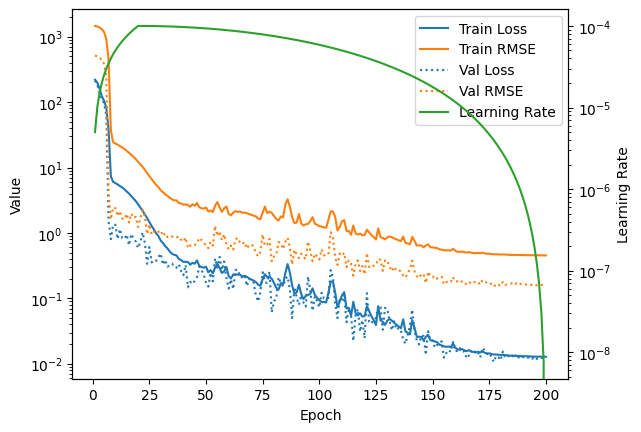

In [254]:
n = np.arange(1, EPOCHS+1)
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

# Comparison with Ground Truth

In [259]:
comparison_entity=["United Kingdom"]

In [260]:
model.eval()
data = []
for years in np.append(val_year, np.append(test_year, ood_test_year)):
    print(years)
    regional_data, global_data = load_tensor(comparison_entity, np.arange(years, years + SEQ_LEN))
    pred = model(global_data, regional_data[:, :-1])

    pred = pred[:, -1, 1:].cpu().detach().numpy()
    data.append(scaler.inverse_transform(pred))

data = np.vstack(data)
test_y = np.arange(2008, 2021)
pd.DataFrame(data, columns=df_global.columns[1:])

2009
2010
2011
2012


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,107.703705,88.502861,12.161222,142.685089,68.921951,82.893890,44.202850,39262.464844,2.058144,354987.46875,43516.929688,281.443970,336485.90625,56.181129,-13.913571
1,107.952202,88.439842,13.512982,135.545624,66.682159,94.492081,48.801144,39006.531250,1.970459,355005.37500,42950.632812,281.675293,378978.93750,56.032398,-13.517701
2,107.744743,88.374542,15.174884,132.048019,61.159473,103.277206,51.262699,39039.269531,1.904432,355229.15625,45621.546875,282.821106,405349.46875,55.960720,-12.952529
3,107.876579,88.211754,16.525469,125.416451,52.183311,111.450523,53.379246,38223.925781,1.792326,355936.31250,45099.871094,283.087738,431784.68750,55.864658,-12.623977


In [ ]:
regional_data = []

for year in test_y:
    year = int(year)

    regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


regional_data = torch.stack(regional_data)
gt = regional_data.numpy()
gt = scaler.inverse_transform(gt[:, 1:])
pd.DataFrame(gt, columns=df_global.columns[1:])

/tmp/ipykernel_12586/3359583700.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,100.0,100.0,2.79,310.50,52.49,21.85,19.317118,41451.902,3.24,515340.0269,47549.34863,281.0,243610.0,55.378051,-3.435973
1,100.0,100.0,3.38,278.73,69.10,25.25,25.289482,39040.560,3.18,466489.9902,38952.21103,281.0,243610.0,55.378051,-3.435973
2,100.0,100.0,3.67,290.59,62.14,26.18,23.308966,39540.008,3.23,482440.0024,39688.61497,281.0,243610.0,55.378051,-3.435973
3,100.0,100.0,4.44,260.88,68.98,35.20,28.537775,37007.074,2.96,445589.9963,42284.88449,281.0,243610.0,55.378051,-3.435973
4,100.0,100.0,4.77,249.25,70.40,41.24,30.934633,37292.910,2.99,467779.9988,42686.80005,281.0,243610.0,55.378051,-3.435973
5,100.0,100.0,6.02,231.56,70.61,53.21,34.841580,36881.977,2.88,453760.0098,43713.81412,281.0,243610.0,55.378051,-3.435973
6,100.0,100.0,7.36,206.94,63.75,64.52,38.265564,34583.770,2.64,415600.0061,47787.24130,281.0,243610.0,55.378051,-3.435973
7,100.0,100.0,8.61,182.43,70.34,82.57,45.598500,34890.320,2.61,401079.9866,45404.56777,281.0,243610.0,55.378051,-3.435973
8,100.0,100.0,8.60,181.56,71.73,82.99,46.009277,34296.684,2.53,380809.9976,41499.55570,281.0,243610.0,55.378051,-3.435973
9,100.0,100.0,9.70,165.91,70.34,98.85,50.489407,34098.812,2.45,367000.0000,40857.75558,281.0,243610.0,55.378051,-3.435973


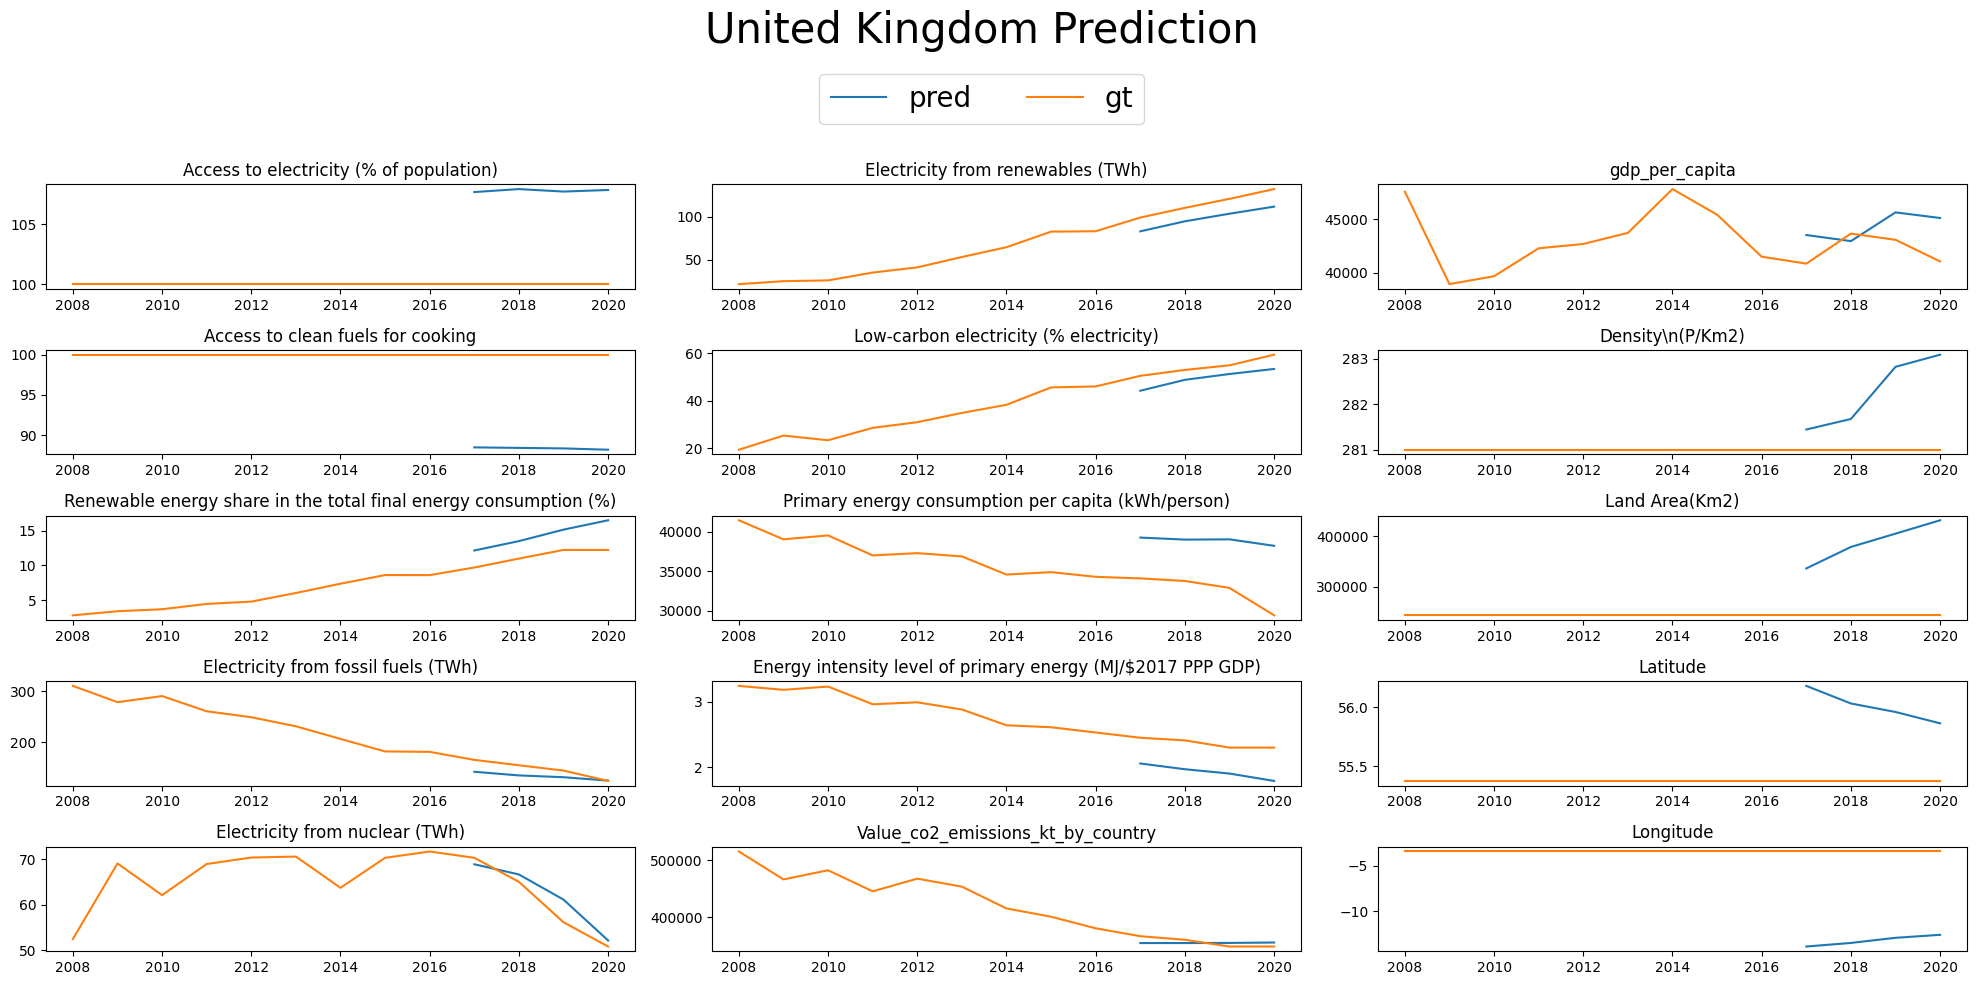

In [281]:
y = test_y[-4:]
cols = df_global.columns[1:]

fig, ax = plt.subplots(ncols=3, nrows=5, figsize=(20, 10))
for i, col in enumerate(cols):
    ax[i%5, i//5].plot(y, data[:, i], label="pred")
    ax[i%5, i//5].plot(test_y, gt[:, i], label="gt")
    ax[i%5, i//5].set_title(col, size=12)

fig.suptitle(comparison_entity[0] + " Prediction", size=30)

# Steal legend from one axis
handles, labels = ax[0, 0].get_legend_handles_labels()

# Put legend below suptitle
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),  # adjust vertically
    ncol=2,
    fontsize=20
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()